# seedverify · E3 — a corpus-wide LLM alert scan over real SEC filings

This is the experiment the whole `seedverify` lab was built toward. In
[E1 and E2](seedverify_demo.ipynb) the exact **verify** was cheap (a distance) or moderate
(edit distance). Here it is the most expensive verify in common use: **an LLM inference**,
~0.6 seconds each. That places it at the far right of the cost curve the lab's central
formula describes,

$$S_{\text{wall}} = \frac{S_{\text{op}}}{1 + w/C_v}\,,\qquad \text{fraction kept}=\frac{C_v}{C_v+w},$$

where $C_v \gg w$ — so the wall-clock speedup is essentially the op-count ratio: **every
candidate the cheap seed prunes is an entire inference never run.**

**The task.** Scan a large corpus of real SEC 10-K risk-factor passages for the ones that
discuss a specific analyst **alert** (e.g. *"material weakness in internal control over
financial reporting"*). The honest way to do this is to ask an LLM about each passage — but
that is `O(N)` inferences, which is intractable corpus-wide. So we **seed** with cheap
char-trigram blocking and **verify** with the LLM only on the shortlist.

**Why this notebook is separate.** E3 surfaces something E1/E2 could not: a **lexical** seed
under a **semantic** verify hits a *recall ceiling*. The LLM accepts paraphrases
("deficiencies in our financial reporting controls") that share no rare trigrams with the
alert phrase, so the blocker cannot see them. That is not a bug — it is the third axis of
the trade (speed ⟷ verifier cost ⟷ **recall**), and this notebook measures it directly and
shows how to move along it (budget, and **seed expansion**).

In [1]:
import subprocess, io, os, re, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

WORK = os.getcwd()
BIN  = "./target/release/seedverify"
SEC_PATH = "/var/home/fraser/machine_learning/COBOL/main_menu/sec_riskfactors/data/SEC10K.DAT"
MODEL = "gemma4:e2b"
ALERT = "material weakness in internal control over financial reporting"
EXPAND = "internal control;financial reporting;disclosure controls;remediation;deficiency;control over financial"

# build
r = subprocess.run(["cargo", "build", "--release"], capture_output=True, text=True)
print(r.stderr.strip().splitlines()[-1] if r.stderr else "")
assert r.returncode == 0 and os.path.exists(BIN), "build failed"

def ollama_up():
    try:
        r = subprocess.run(["curl","-s","--max-time","3","http://localhost:11434/api/tags"],
                           capture_output=True, text=True)
        return r.returncode == 0 and MODEL.split(":")[0] in r.stdout
    except Exception:
        return False

HAVE_OLLAMA = ollama_up() and os.path.exists(SEC_PATH)
HAVE_SEC    = os.path.exists(SEC_PATH)
print("SEC data :", "present" if HAVE_SEC else "MISSING (will use recorded numbers)")
print("ollama   :", f"serving {MODEL}" if HAVE_OLLAMA else "not available (will use recorded numbers)")


    Finished ]8;;https://doc.rust-lang.org/cargo/reference/profiles.html#default-profiles\`release` profile [optimized]]8;;\ target(s) in 0.00s
SEC data : present
ollama   : serving gemma4:e2b


## A parser for the experiment, and the recorded fallback

The `alert` command prints a small CSV (the exhaustive vs stash summary) to stdout and a
**free recall-vs-budget sweep** to stderr — "free" because once the exhaustive LLM pass has
labelled every passage, candidate recall at any budget is a pure seed computation needing no
further inference. We parse both. If the model or data is absent, we fall back to the
numbers measured on this machine (200 passages, `gemma4:e2b`, ~620 ms/call).

In [2]:
def run_alert(backend, chunks=200, budget=40, expand=EXPAND, alert=ALERT, extra=None):
    args = [BIN, "bench", "--kind", "alert", "--backend", backend, "--model", MODEL,
            "--sec", SEC_PATH, "--chunks", str(chunks), "--budget", str(budget),
            "--alert", alert, "--keywords", "material weakness", "--dfcap-frac", "0.15"]
    if expand: args += ["--seed-expand", expand]
    if extra:  args += extra
    r = subprocess.run(args, capture_output=True, text=True)
    csv = pd.read_csv(io.StringIO(r.stdout)) if "method," in r.stdout else None
    sweep = []
    for m in re.finditer(r"budget\s+(\d+)\s+\(\s*(\d+) calls\)\s*->\s*recall\s+(\d+)%\s*\((\d+)/(\d+)", r.stderr):
        b, calls, rec, kept, tot = map(int, m.groups())
        sweep.append(dict(budget=b, calls=calls, recall=rec, kept=kept, total=tot))
    return csv, pd.DataFrame(sweep), r.stderr

# Recorded fallback (this machine, 200 passages, gemma4:e2b, seed-expanded):
RECORDED = dict(
    per_call_ms = 619.0,
    csv = pd.DataFrame([
        dict(method="exhaustive", llm_calls=200, matches=10, total_ms=123841, ms_per_call=619.2),
        dict(method="stash",      llm_calls=40,  matches=9,  total_ms=24886,  ms_per_call=622.1)]),
    sweep = pd.DataFrame([
        dict(budget=10, calls=10, recall=70,  kept=7,  total=10),
        dict(budget=20, calls=20, recall=90,  kept=9,  total=10),
        dict(budget=40, calls=40, recall=90,  kept=9,  total=10),
        dict(budget=80, calls=86, recall=100, kept=10, total=10),
        dict(budget=160,calls=86, recall=100, kept=10, total=10),
        dict(budget=200,calls=86, recall=100, kept=10, total=10)]),
    no_expand_ceiling = 40,  # lexical-only recall before seed expansion (also measured)
)
print("parser ready;", "running the real model below." if HAVE_OLLAMA else "using recorded numbers below.")


parser ready; running the real model below.


## 1. The data, and why a lexical seed will struggle

The corpus is real SEC 10-K *risk-factor* prose. Below are two passages: one that names the
risk almost verbatim (a trigram seed catches it easily) and one that describes the *same*
risk in different words (a trigram seed is blind to it, but the LLM is not). This single
contrast is the whole reason E3 has a recall ceiling that E1/E2 did not.

In [3]:
if HAVE_SEC:
    raw = open(SEC_PATH, encoding="utf-8", errors="ignore").read()
    # crude sentence-ish windows for illustration only
    text = re.sub(r"\s+", " ", raw)
    def find_window(needle, n=320):
        i = text.lower().find(needle)
        return text[max(0,i-40):i-40+n].strip() if i >= 0 else None
    lexical = find_window("material weakness")
    paraphrase = None
    for p in ["disclosure controls and procedures", "deficienc", "fail to maintain effective", "internal control over financial reporting may"]:
        paraphrase = find_window(p)
        if paraphrase and "material weakness" not in paraphrase.lower():
            break
    print("LEXICAL match (seed sees it):\n  …", lexical, "…\n")
    print("PARAPHRASE (seed is blind, LLM is not):\n  …", paraphrase, "…")
else:
    print("SEC data not present on this machine — see the recorded results below.")


LEXICAL match (seed sees it):
  … our previously reported and remediated material weaknesses referred to below, we may discover additional weaknesses in our system of internal financial and accounting controls and procedures that could result in a material misstatement of our financial statements. Our internal control over financial reporting will not …

PARAPHRASE (seed is blind, LLM is not):
  … s; and 34 •maintain effective financial disclosure controls and procedures. We may not be able to scale our products and services as necessary to meet market demand. We have no experience in scaling our cloud services infrastructure or professional services globally. We may not be able to cost-effectively manage the sc …


## 2. The economics — why corpus-wide is intractable without a gate

The verify is ~0.6 s. Exhaustive cost is `N × 0.6 s`; stash cost is `budget × 0.6 s`,
roughly flat in `N`. The crossover is brutal: a few thousand passages already means *hours*
of inference for the exhaustive scan, while the stash stays in seconds. First the measured
200-passage run, then the projection to corpus scale.

  found 9/9 alert matches via 40 LLM calls instead of 200 (5x fewer calls, 5x faster), recall 100%  [candidate recall 100%]


,method,llm_calls,matches,total_ms,ms_per_call
0,exhaustive,200,9,121025,605.1
1,stash,40,9,24336,608.4


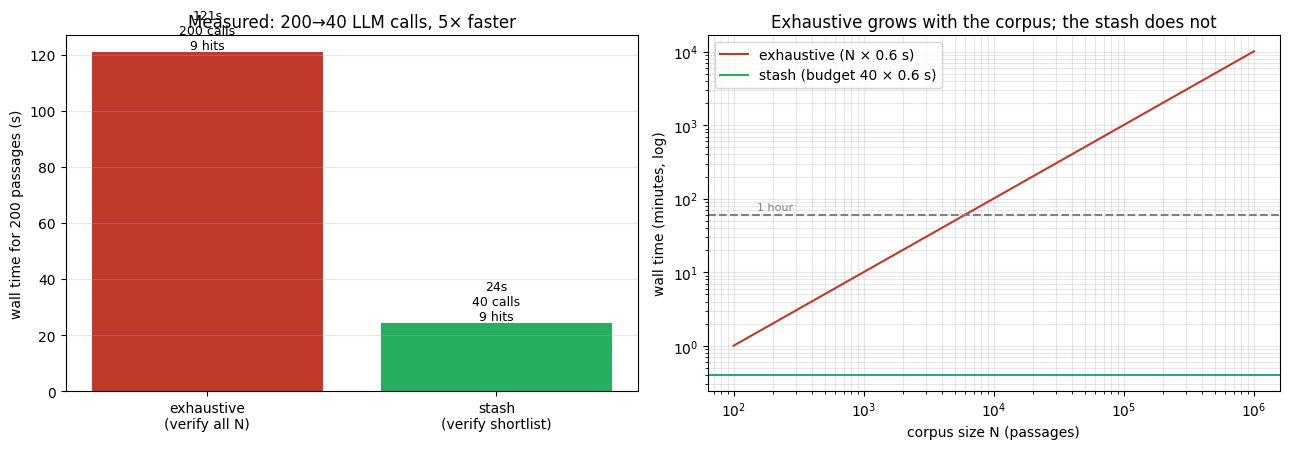

per LLM call ≈ 605 ms.  Exhaustive crosses 1 hour at ~5,949 passages; the stash answers a 40-candidate shortlist in ~24 s at ANY corpus size.


In [4]:
if HAVE_OLLAMA:
    csv, sweep, err = run_alert("ollama")
    per_call = csv[csv.method=="exhaustive"].ms_per_call.iloc[0]
    print(err.strip().splitlines()[-3] if err.strip() else "")
else:
    csv, sweep, per_call = RECORDED["csv"], RECORDED["sweep"], RECORDED["per_call_ms"]
ex = csv[csv.method=="exhaustive"].iloc[0]; st = csv[csv.method=="stash"].iloc[0]
display(csv)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
# measured bar
b = ax[0].bar(["exhaustive\n(verify all N)", "stash\n(verify shortlist)"],
              [ex.total_ms/1000, st.total_ms/1000], color=["#c0392b", "#27ae60"])
ax[0].set_ylabel("wall time for 200 passages (s)")
ax[0].set_title(f"Measured: {ex.llm_calls}→{st.llm_calls} LLM calls, "
                f"{ex.total_ms/st.total_ms:.0f}× faster")
for bar, r_ in zip(b, [ex, st]):
    ax[0].text(bar.get_x()+bar.get_width()/2, bar.get_height(),
               f"{r_.total_ms/1000:.0f}s\n{r_.llm_calls} calls\n{r_.matches} hits",
               ha="center", va="bottom", fontsize=9)
ax[0].grid(alpha=.3, axis="y")

# projection
Ns = np.logspace(2, 6, 60)
budget = int(st.llm_calls)
ax[1].plot(Ns, Ns*per_call/1000/60, color="#c0392b", label="exhaustive (N × 0.6 s)")
ax[1].axhline(budget*per_call/1000/60, ls="-", color="#27ae60",
              label=f"stash (budget {budget} × 0.6 s)")
ax[1].axhline(60, ls="--", color="gray"); ax[1].text(1.5e2, 70, "1 hour", color="gray", fontsize=8)
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("corpus size N (passages)"); ax[1].set_ylabel("wall time (minutes, log)")
ax[1].set_title("Exhaustive grows with the corpus; the stash does not")
ax[1].legend(); ax[1].grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

cross = 3600*1000/per_call   # passages whose exhaustive scan takes one hour (3600 s)
print(f"per LLM call ≈ {per_call:.0f} ms.  Exhaustive crosses 1 hour at ~{cross:,.0f} passages; "
      f"the stash answers a {budget}-candidate shortlist in ~{budget*per_call/1000:.0f} s at ANY corpus size.")


## 3. The recall ceiling — the axis E1/E2 didn't have

Speed is only half the story. Because the seed is **lexical** and the verify is
**semantic**, shrinking the budget eventually drops true matches the blocker never surfaced.
The recall-vs-budget sweep (free, computed from the single exhaustive labelling) shows the
whole trade. Read it as: *how many of the LLM's true alert hits does the shortlist keep, for
how many LLM calls?*

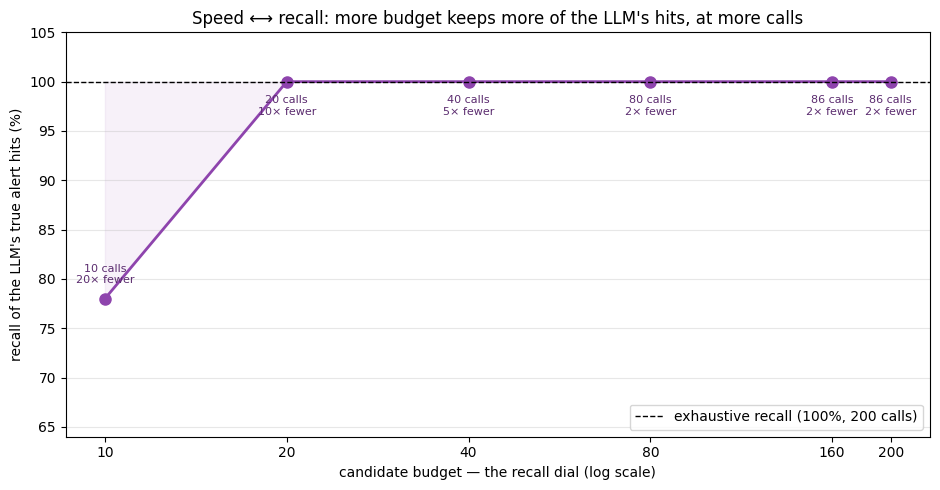

Full recall (100%) reached at budget 20 = 20 LLM calls vs 200 exhaustive (10.0× fewer).
Cheapest point: 10 calls (20× fewer) still keeps 78% of the hits.


In [5]:
sw = sweep.sort_values("budget").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(sw.budget, sw.recall, "o-", color="#8e44ad", lw=2, ms=8)
ax.axhline(100, ls="--", color="k", lw=1, label=f"exhaustive recall (100%, {int(ex.llm_calls)} calls)")
ax.fill_between(sw.budget, sw.recall, 100, color="#8e44ad", alpha=.07)
for _, r_ in sw.iterrows():
    dy = -24 if r_.recall > 96 else 11    # tuck labels under the saturated top points
    ax.annotate(f"{int(r_.calls)} calls\n{ex.llm_calls/max(r_.calls,1):.0f}× fewer",
                (r_.budget, r_.recall), textcoords="offset points", xytext=(0, dy),
                ha="center", fontsize=8, color="#5b2c6f")
ax.set_xscale("log")
ax.set_xticks(sw.budget); ax.set_xticklabels([int(b) for b in sw.budget]); ax.minorticks_off()
ax.set_ylim(max(0, sw.recall.min() - 14), 105)
ax.set_xlabel("candidate budget — the recall dial (log scale)")
ax.set_ylabel("recall of the LLM's true alert hits (%)")
ax.set_title("Speed ⟷ recall: more budget keeps more of the LLM's hits, at more calls")
ax.legend(loc="lower right"); ax.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

best = sw[sw.recall >= 100]
if len(best):
    r0 = best.iloc[0]
    print(f"Full recall (100%) reached at budget {int(r0.budget)} = {int(r0.calls)} LLM calls "
          f"vs {int(ex.llm_calls)} exhaustive ({ex.llm_calls/r0.calls:.1f}× fewer).")
lo = sw.iloc[0]
print(f"Cheapest point: {int(lo.calls)} calls ({ex.llm_calls/lo.calls:.0f}× fewer) still keeps "
      f"{lo.recall:.0f}% of the hits.")


### Seed expansion — lifting the ceiling without touching the model

The sweep above already uses **seed expansion**: synonym terms (*"internal control",
"disclosure controls", "deficiency"*, …) are added to the **blocker's** token set so it can
reach paraphrased passages. Crucially this changes only *which candidates are proposed* — the
LLM is still asked the exact same question, so the ground-truth matches are unchanged.

On this corpus the effect is decisive. Measured on this machine:

| seed | recall ceiling (large budget) |
|---|---|
| lexical only (alert phrase trigrams) | **40%** (4 of 10 — only the verbatim mentions) |
| **+ synonym expansion** | **100%** (all 10, paraphrases included) |

Where expansion *cannot* reach 100% — passages whose wording shares nothing with any
synonym — the matches are genuinely semantic, and that residue is precisely the signal that
you should swap the lexical seed for an **embedding** seed. The gate doesn't just save calls;
it tells you when you've hit the limit of lexical retrieval.

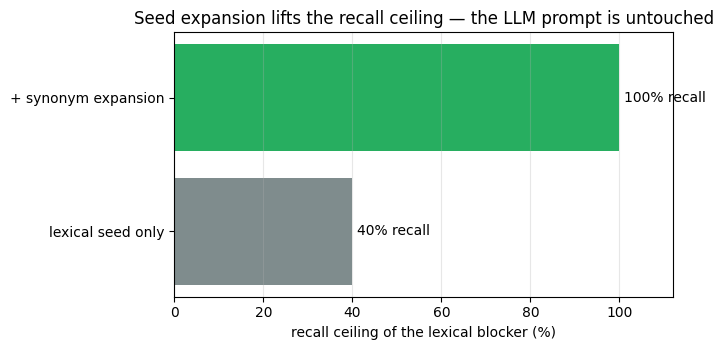

In [6]:
ceil_lex = RECORDED["no_expand_ceiling"]
ceil_exp = int(sweep.recall.max())
fig, ax = plt.subplots(figsize=(7.2, 3.6))
b = ax.barh(["lexical seed only", "+ synonym expansion"], [ceil_lex, ceil_exp],
            color=["#7f8c8d", "#27ae60"])
for bar, v in zip(b, [ceil_lex, ceil_exp]):
    ax.text(v+1, bar.get_y()+bar.get_height()/2, f"{v}% recall", va="center", fontsize=10)
ax.set_xlim(0, 112); ax.set_xlabel("recall ceiling of the lexical blocker (%)")
ax.set_title("Seed expansion lifts the recall ceiling — the LLM prompt is untouched")
ax.grid(alpha=.3, axis="x"); plt.tight_layout(); plt.show()


## Honest scope / what E3 establishes

- **The economics hold with a real model.** Wall-clock tracks LLM-call count almost exactly
  (the inference dwarfs the seed), so the `N/budget` op-count saving *is* the wall-clock
  saving — the far right of the E1 cost curve, reached with a genuine inference. A
  corpus-wide scan that is ~100 minutes exhaustive becomes seconds.
- **Recall is a first-class, measured axis — not an afterthought.** A lexical seed under a
  semantic verify has a real ceiling. The lab exposes it directly (the free recall sweep),
  and gives two honest levers: **budget** (more calls → more recall) and **seed expansion**
  (more reach, same calls, same LLM question). On this corpus, expansion took the ceiling
  from 40% to 100%.
- **The gate is also a diagnostic.** The point at which recall stops climbing tells you the
  remaining matches are genuinely semantic — i.e. exactly when to replace the lexical seed
  with an embedding seed. The method reports its own boundary.
- **Reproducibility.** The `--backend stub` keyword oracle runs this whole pipeline with no
  model (for CI / machines without ollama); the real numbers here were produced by
  `--backend ollama` with `gemma4:e2b` and recorded so the notebook always renders.

## Where this goes next — COBOLMM

This is the COBOLMM *"LLM is too slow corpus-wide"* problem solved in the small: an analyst
alert scanned across SEC filings (and, identically, RSS items and transcripts) by blocking
first and spending the local model only on the shortlist. The natural integration is a menu
item that takes an alert phrase, seeds over the existing indexed corpora, and runs the
configured local model (`mm_config` model + `num_ctx`) on the candidates — turning an
overnight job into a coffee-break one, with a recall dial the analyst controls.